#### **RESULTADOS MONTECARLO EVALUANDO LOS 3 MODELOS**

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 0) CARGAR DATOS
# =========================
path = "/home/oisanchezp/Thesis/data/processed/resultados_paquetec_3modelos_T1_P33_MC50.csv"  # <-- ajusta si es otro
df = pd.read_csv(path)

# (por si vienen con mayúsculas raras o espacios)
df.columns = [c.strip() for c in df.columns]

# métricas de interés
metrics = ["auc", "f1", "recall", "precision", "pofd"]
count_cols = ["tp", "tn", "fp", "fn"]

# =========================
# 1) TABLA RESUMEN (mean, median, sd, min, max)
# =========================
resumen = (
    df.groupby("modelo")[metrics]
      .agg(["mean", "median", "std", "min", "max"])
)

# aplanar columnas para que quede bonito
resumen.columns = [f"{m}_{stat}" for (m, stat) in resumen.columns]
resumen = resumen.reset_index()

print("\n=== RESUMEN MÉTRICAS (por modelo) ===")
print(resumen.to_string(index=False))

# # si quieres guardarla:
# out_resumen = "/home/oisanchezp/Thesis/data/processed/resumen_metricas_por_modelo.csv"
# resumen.to_csv(out_resumen, index=False)
# print(f"\nGuardado resumen en: {out_resumen}")


=== RESUMEN MÉTRICAS (por modelo) ===
      modelo  auc_mean  auc_median  auc_std  auc_min  auc_max  f1_mean  f1_median   f1_std   f1_min   f1_max  recall_mean  recall_median  recall_std  recall_min  recall_max  precision_mean  precision_median  precision_std  precision_min  precision_max  pofd_mean  pofd_median  pofd_std  pofd_min  pofd_max
         GAM  0.987232    0.987504 0.002758 0.979724 0.991751 0.934187   0.933333 0.010895 0.911111 0.957854     0.939708       0.939850    0.008108    0.924812    0.954887        0.928994          0.929144       0.020508       0.881944       0.976562   0.038618     0.038439  0.011972   0.01200  0.067460
       Logit  0.987049    0.986917 0.002495 0.981265 0.991020 0.919998   0.918629 0.010893 0.899281 0.947368     0.952939       0.954887    0.007867    0.939850    0.969925        0.889547          0.887324       0.020733       0.854305       0.947368   0.063505     0.064257  0.013265   0.02800  0.087302
RandomForest  0.989505    0.989747 0.002573

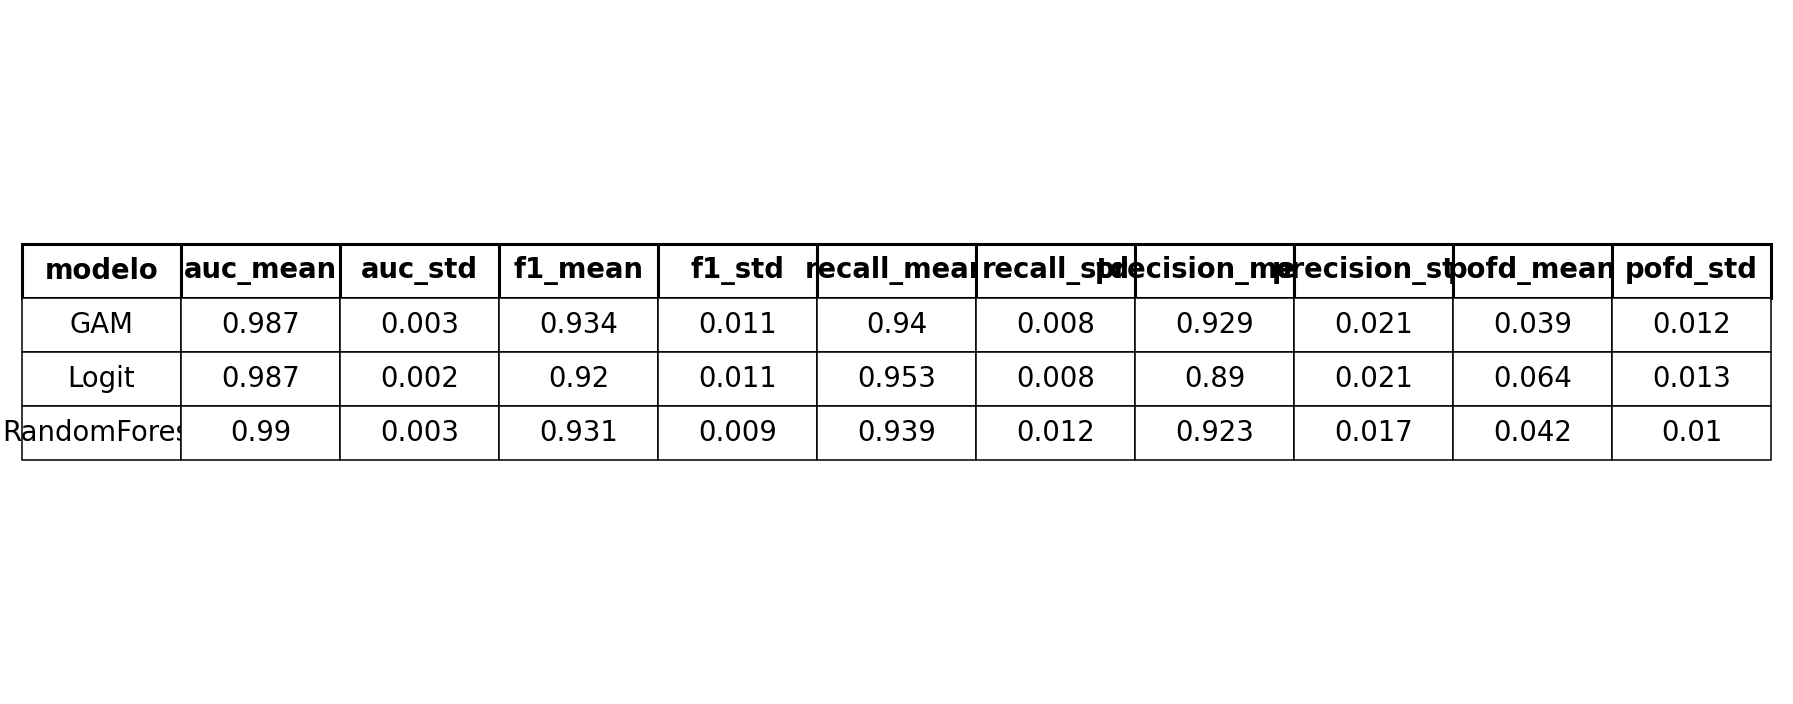

      modelo  auc_mean  auc_std  f1_mean   f1_std  recall_mean  recall_std  precision_mean  precision_std  pofd_mean  pofd_std
         GAM  0.987232 0.002758 0.934187 0.010895     0.939708    0.008108        0.928994       0.020508   0.038618  0.011972
       Logit  0.987049 0.002495 0.919998 0.010893     0.952939    0.007867        0.889547       0.020733   0.063505  0.013265
RandomForest  0.989505 0.002573 0.930744 0.009490     0.938959    0.011619        0.922918       0.016739   0.042089  0.009971


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

#out_fig_dir = "/home/oisanchezp/Thesis/figuras"
#os.makedirs(out_fig_dir, exist_ok=True)

# métricas que quieres
metrics = ["auc", "f1", "recall", "precision", "pofd"]

# 1) resumen solo mean y std
resumen_ms = (
    df.groupby("modelo")[metrics]
      .agg(["mean", "std"])
)

# aplanar nombres: auc_mean, auc_std, ...
resumen_ms.columns = [f"{m}_{stat}" for (m, stat) in resumen_ms.columns]
resumen_ms = resumen_ms.reset_index()

# 2) (opcional) redondear
res_img = resumen_ms.copy()
num_cols = res_img.columns.drop("modelo")
res_img[num_cols] = res_img[num_cols].astype(float).round(3)

# 3) tabla como imagen (más compacta)
fig_w = max(8, 0.75 * len(res_img.columns))
fig_h = 1.2 + 0.7 * len(res_img)   # crece con #modelos (pocas filas)
fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=220)
ax.axis("off")

tbl = ax.table(
    cellText=res_img.values,
    colLabels=res_img.columns,
    cellLoc="center",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.25)

# encabezado en negrita
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_text_props(weight="bold")
        cell.set_linewidth(1.0)
    else:
        cell.set_linewidth(0.5)

#out_png = os.path.join(out_fig_dir, "tabla_resumen_mean_std.png")
plt.tight_layout()
#plt.savefig(out_png, bbox_inches="tight", dpi=300)
plt.show()

print(resumen_ms.to_string(index=False))
#print(f"Guardada en: {out_png}")



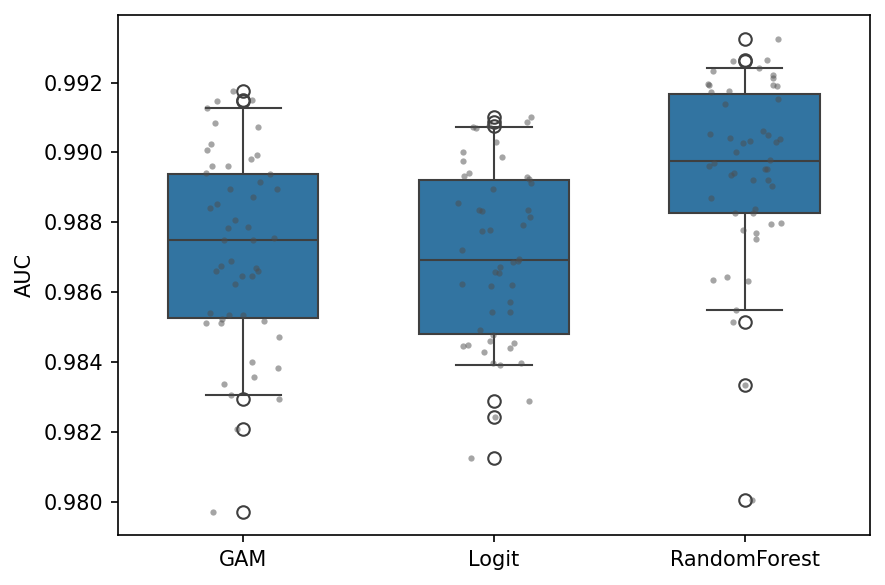

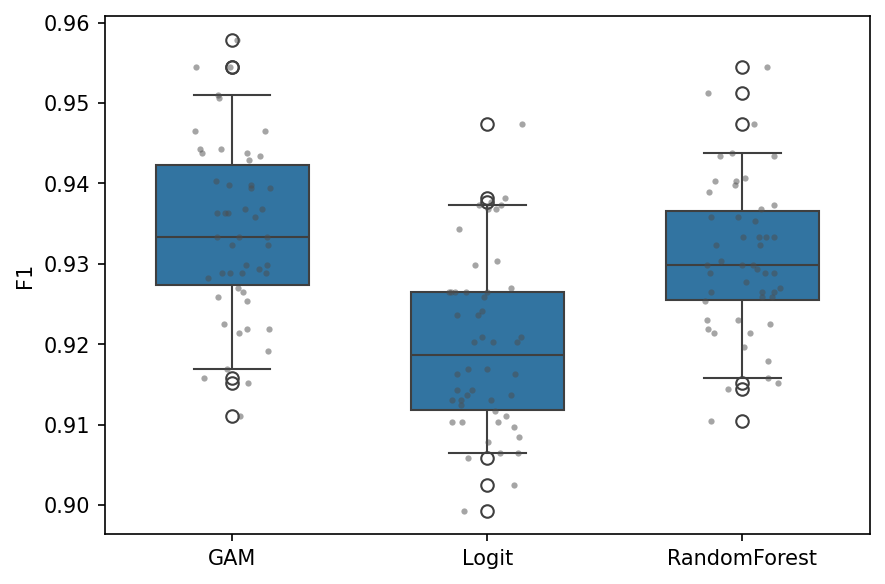

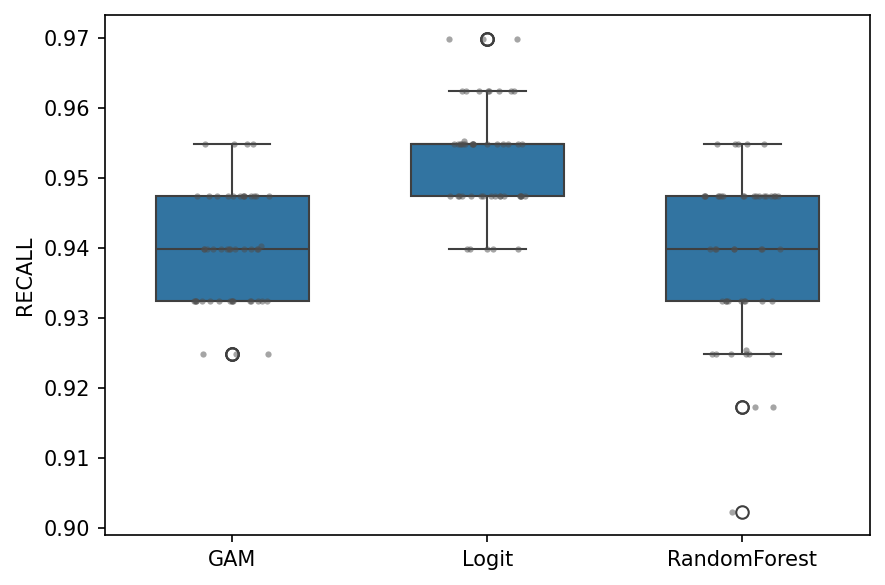

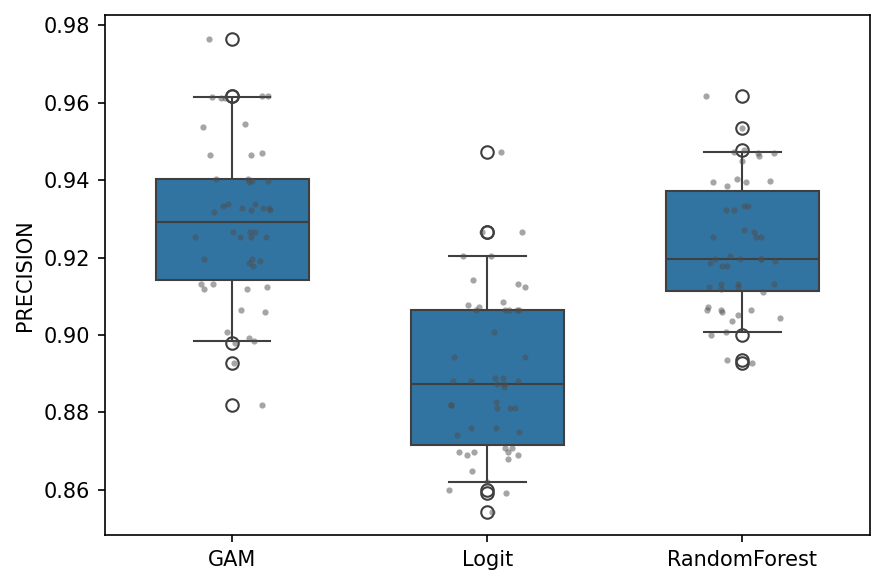

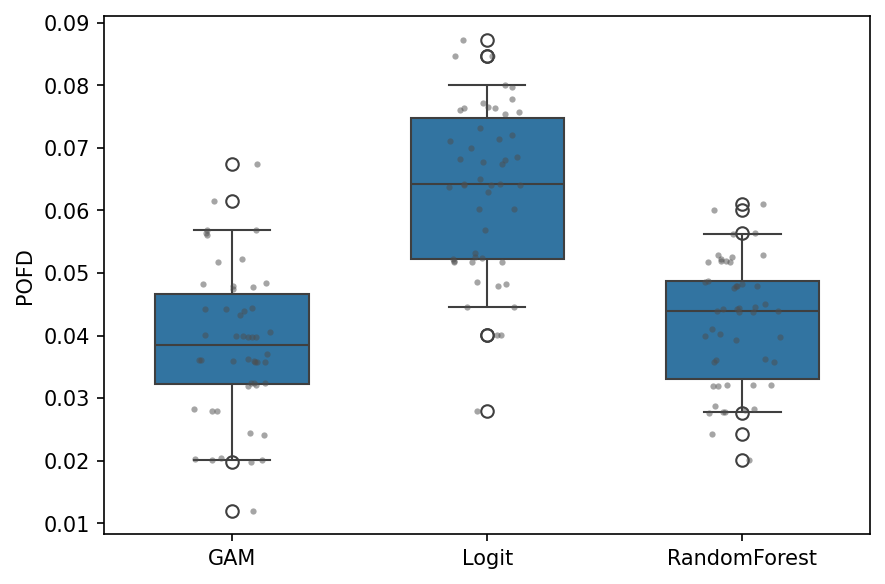

In [4]:
# =========================
# 2) BOXPLOTS por métrica (modelo en x)
# =========================
# out_fig_dir = "/home/oisanchezp/Thesis/figuras"
# os.makedirs(out_fig_dir, exist_ok=True)

for m in metrics:
    plt.figure(figsize=(6, 4), dpi=150)

    sns.boxplot(
        data=df,
        x="modelo",
        y=m,
        whis=(5, 95),
        width=0.6
    )

    sns.stripplot(
        data=df,
        x="modelo",
        y=m,
        color="0.3",
        alpha=0.5,
        jitter=0.15,
        size=3
    )

    plt.ylabel(m.upper())
    plt.xlabel("")
    plt.tight_layout()

    #out_png = os.path.join(out_fig_dir, f"{m}_boxplot_modelos.png")
    #plt.savefig(out_png, dpi=300)
    plt.show()

    #print(f"Figura guardada: {out_png}")


=== Métrica: AUC ===


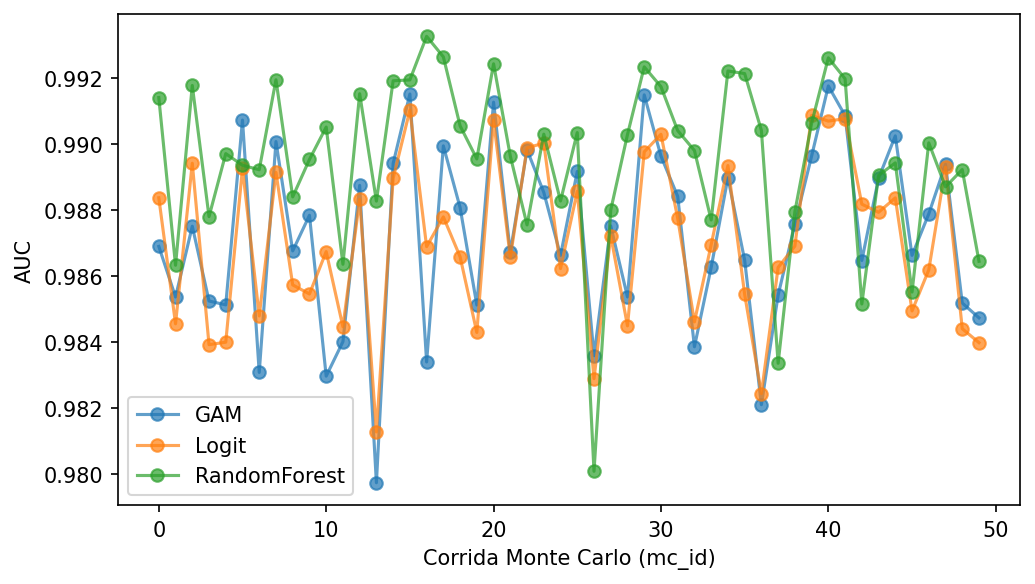


=== Métrica: F1 ===


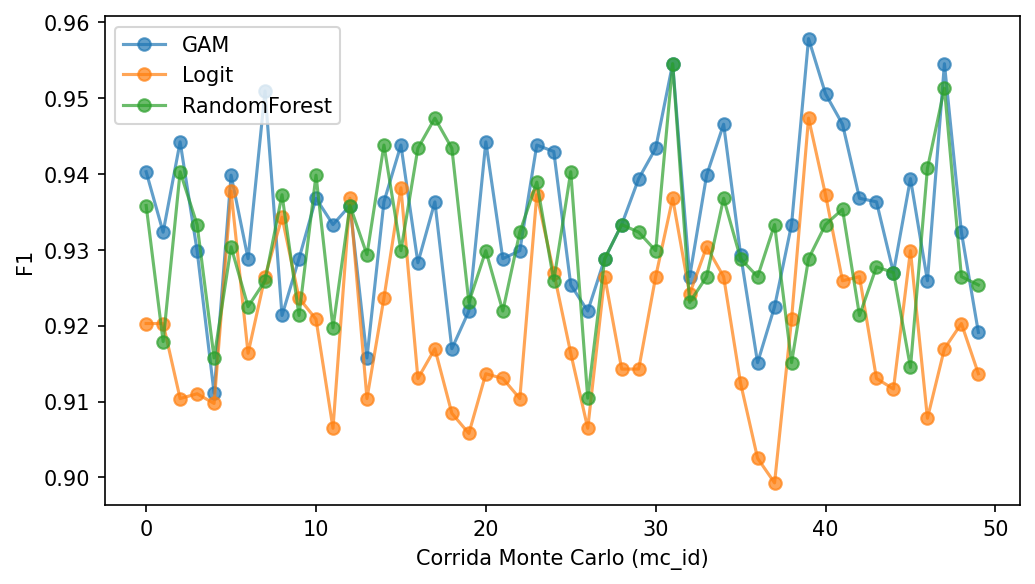


=== Métrica: RECALL ===


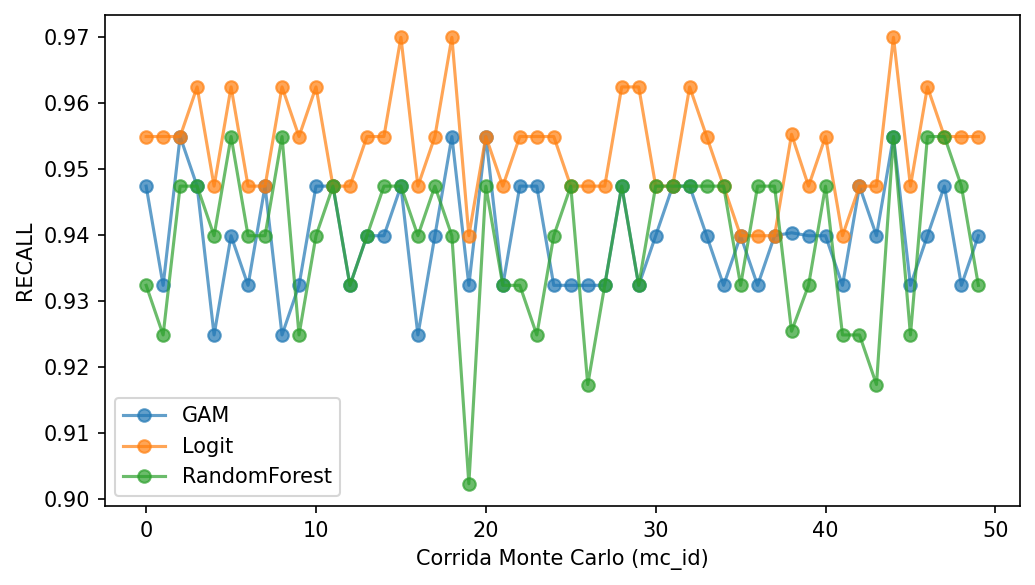


=== Métrica: PRECISION ===


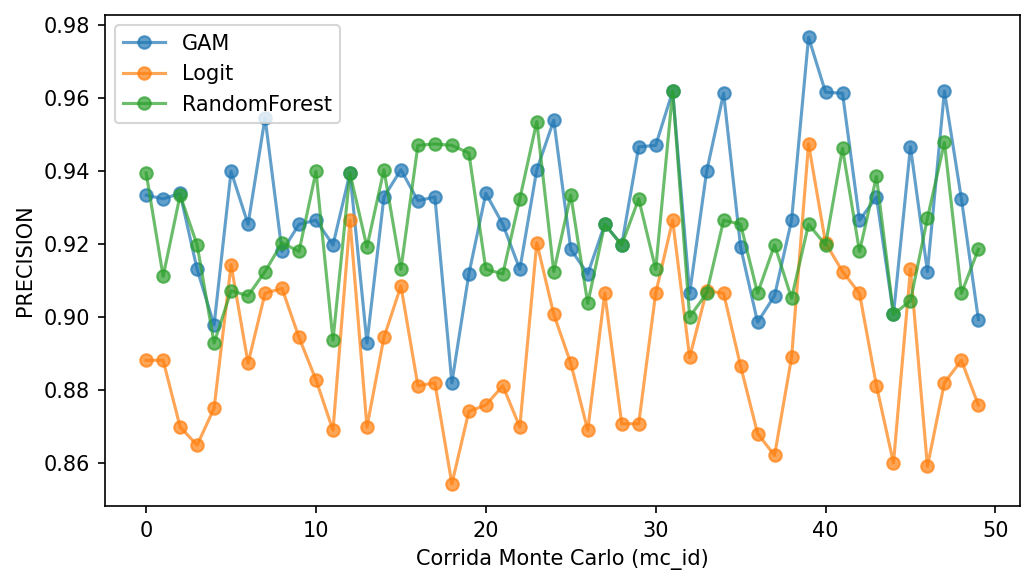


=== Métrica: POFD ===


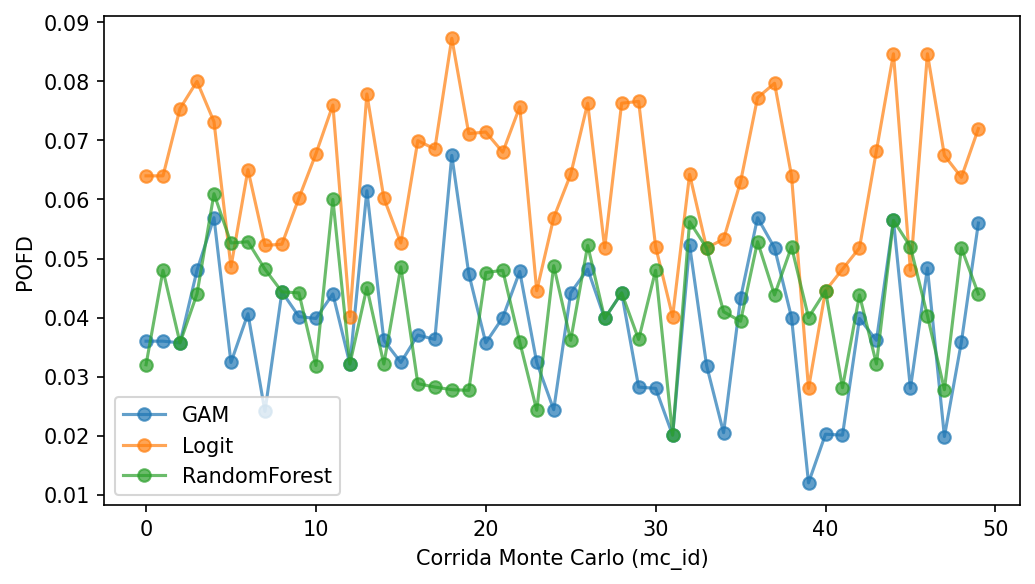

In [5]:
# =========================
# 3) LÍNEAS por métrica (x=mc_id, y=m, color=modelo)
# =========================
for m in metrics:
    pivot = df.pivot(index="mc_id", columns="modelo", values=m).sort_index()

    plt.figure(figsize=(7, 4), dpi=150)

    for modelo in pivot.columns:
        plt.plot(
            pivot.index,
            pivot[modelo],
            marker="o",
            linestyle="-",
            alpha=0.7,
            label=modelo
        )

    plt.xlabel("Corrida Monte Carlo (mc_id)")
    plt.ylabel(m.upper())
    plt.legend()
    plt.tight_layout()

    #out_png = os.path.join(out_fig_dir, f"{m}_lineas_por_mc.png")
    #plt.savefig(out_png, dpi=300)
    print(f"\n=== Métrica: {m.upper()} ===")
    plt.show()

    #print(f"Figura guardada: {out_png}")


=== Conteo: TP ===


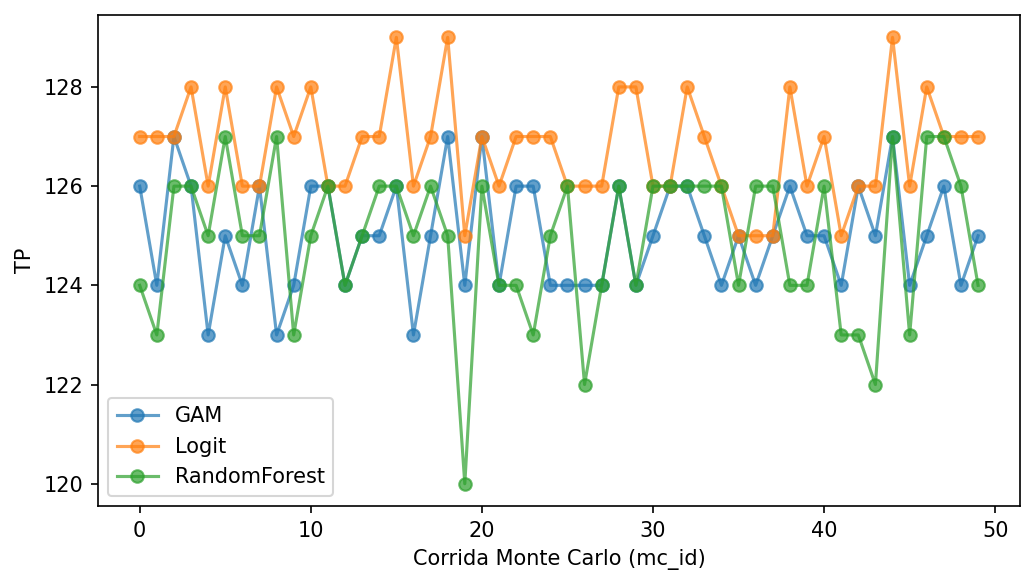


=== Conteo: TN ===


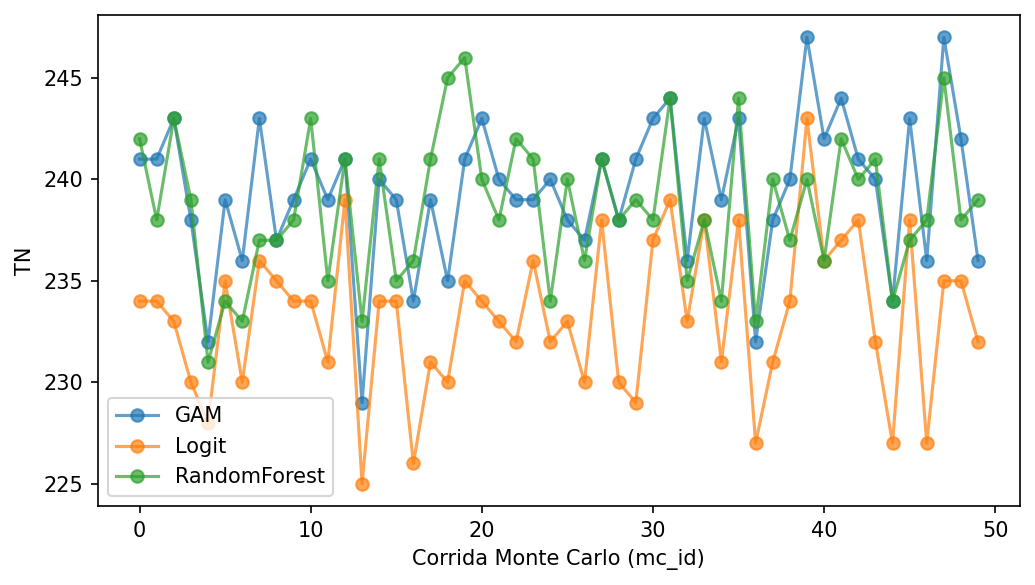


=== Conteo: FP ===


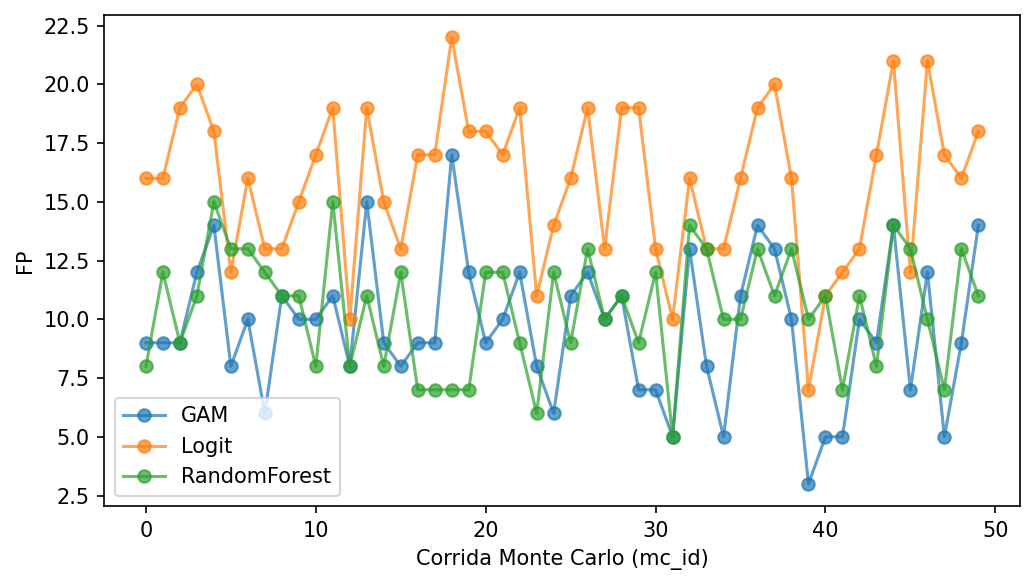


=== Conteo: FN ===


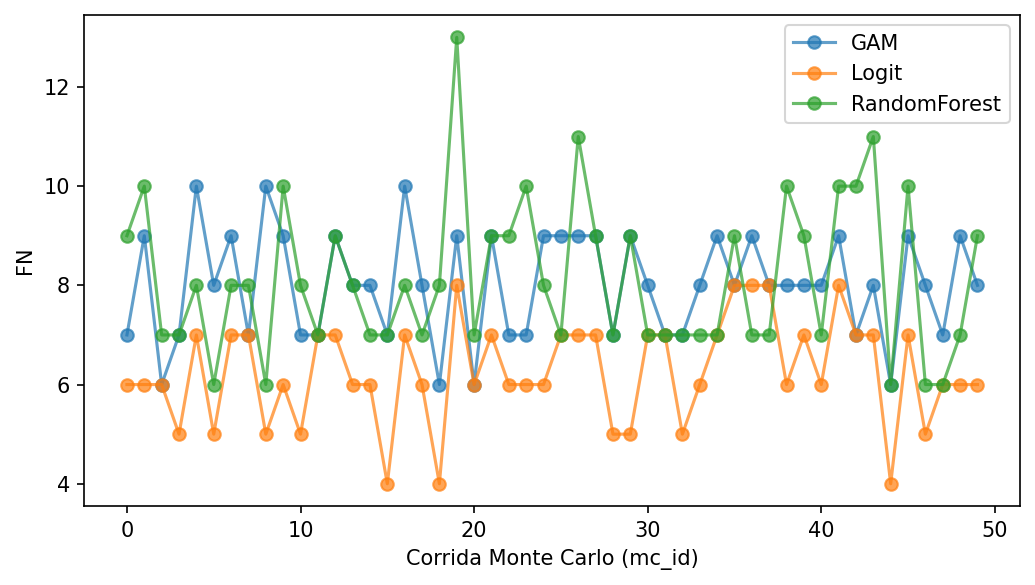

In [6]:
# =========================
# 4) TP/TN/FP/FN: líneas por corrida, 1 figura por variable
#    (x=mc_id, y=conteo, color=modelo)
# =========================
for c in count_cols:
    pivot_c = df.pivot(index="mc_id", columns="modelo", values=c).sort_index()

    plt.figure(figsize=(7, 4), dpi=150)

    for modelo in pivot_c.columns:
        plt.plot(
            pivot_c.index,
            pivot_c[modelo],
            marker="o",
            linestyle="-",
            alpha=0.7,
            label=modelo
        )

    plt.xlabel("Corrida Monte Carlo (mc_id)")
    plt.ylabel(c.upper())
    plt.legend()
    plt.tight_layout()

    #out_png = os.path.join(out_fig_dir, f"{c}_lineas_por_mc.png")
    #plt.savefig(out_png, dpi=300)
    print(f"\n=== Conteo: {c.upper()} ===")
    plt.show()

    #print(f"Figura guardada: {out_png}")